In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../data/clean.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')

# Merge review scores in
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

df['order_month'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M')

os.makedirs('../charts', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

print(f"Loaded: {df.shape[0]:,} rows")
print(f"Columns: {list(df.columns)}")

Loaded: 115,720 rows
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'product_category_name_english', 'delivery_days', 'delivered_on_time', 'order_month', 'order_year', 'on_time_flag', 'review_score']


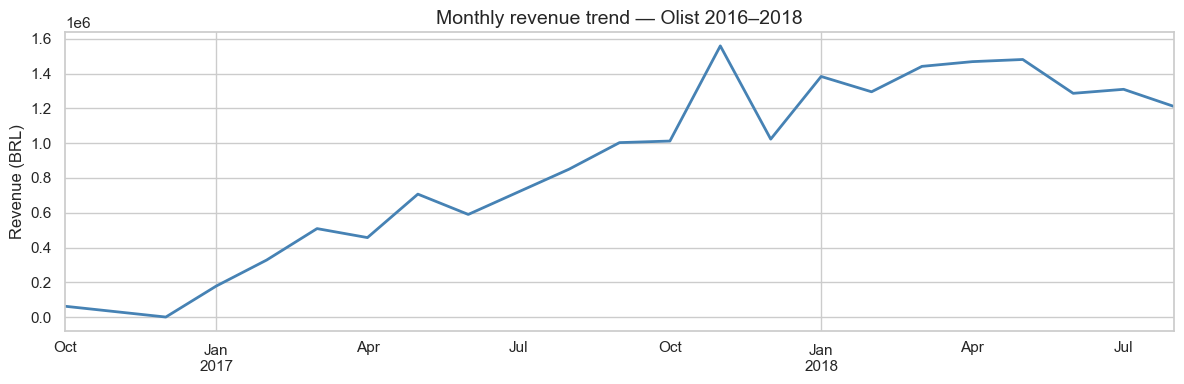

Chart saved


In [2]:
monthly = df.groupby('order_month')['payment_value'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color='steelblue', linewidth=2)
ax.set_title('Monthly revenue trend — Olist 2016–2018', fontsize=14)
ax.set_ylabel('Revenue (BRL)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../charts/01_monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved")

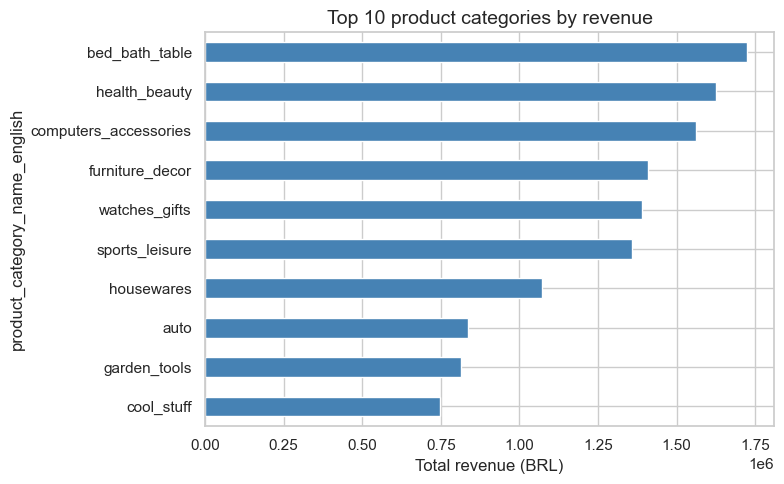

Chart saved


In [3]:
top_cats = (df.groupby('product_category_name_english')['payment_value']
              .sum()
              .sort_values(ascending=True)
              .tail(10))

fig, ax = plt.subplots(figsize=(8, 5))
top_cats.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 product categories by revenue', fontsize=14)
ax.set_xlabel('Total revenue (BRL)')
plt.tight_layout()
plt.savefig('../charts/02_top_categories.png', dpi=150)
plt.show()
print("Chart saved")

C:\Users\iamal\AppData\Local\Temp\ipykernel_23336\491640842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='review_score', y='delivery_days',


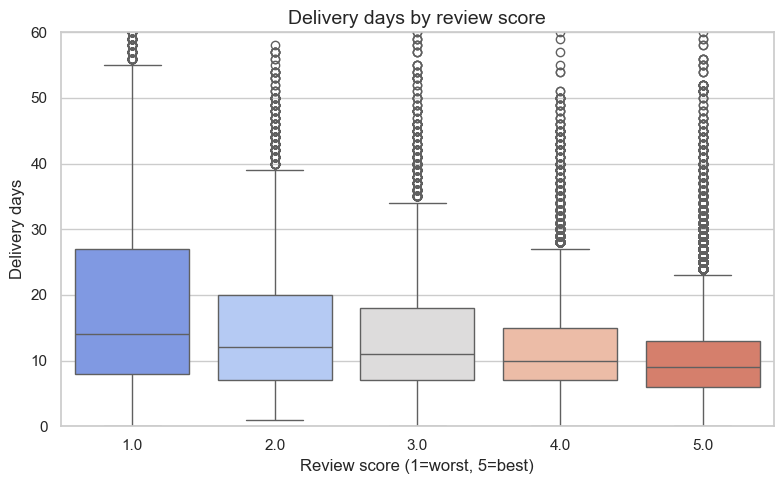

Chart saved


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='review_score', y='delivery_days',
            palette='coolwarm', ax=ax)
ax.set_title('Delivery days by review score', fontsize=14)
ax.set_xlabel('Review score (1=worst, 5=best)')
ax.set_ylabel('Delivery days')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('../charts/03_delivery_vs_score.png', dpi=150)
plt.show()
print("Chart saved")

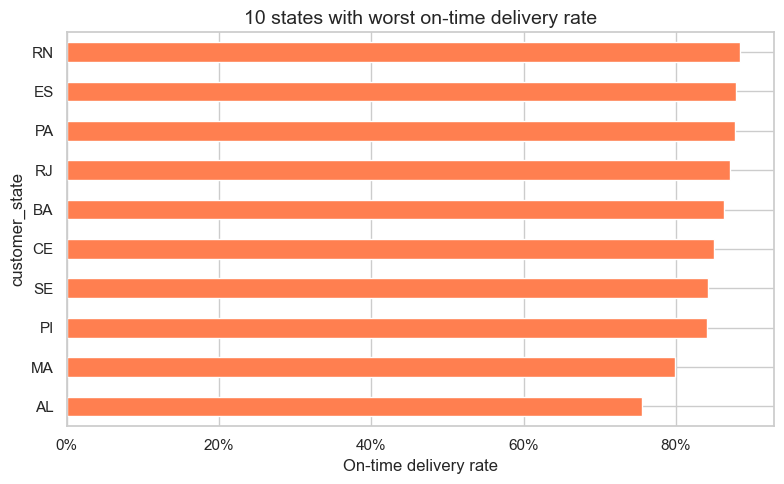

Chart saved


In [5]:
on_time = (df.groupby('customer_state')['delivered_on_time']
             .mean()
             .sort_values()
             .head(10))

fig, ax = plt.subplots(figsize=(8, 5))
on_time.plot(kind='barh', ax=ax, color='coral')
ax.set_title('10 states with worst on-time delivery rate', fontsize=14)
ax.set_xlabel('On-time delivery rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.savefig('../charts/04_ontime_by_state.png', dpi=150)
plt.show()
print("Chart saved")

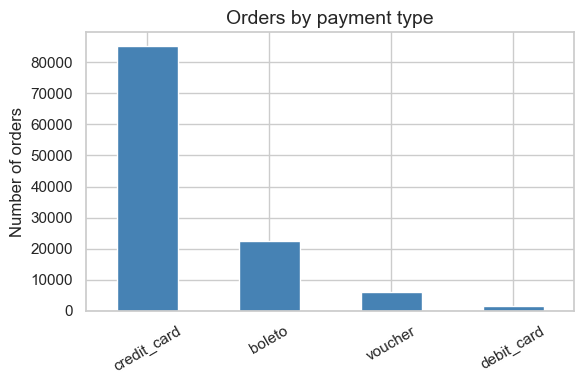

Chart saved


In [6]:
payment_counts = df['payment_type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
payment_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Orders by payment type', fontsize=14)
ax.set_ylabel('Number of orders')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../charts/05_payment_types.png', dpi=150)
plt.show()
print("Chart saved")

In [7]:
# Save clean data with review score included
df.to_csv('../data/clean.csv', index=False)
print("Saved with review_score column")
print(df.columns.tolist())

Saved with review_score column
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'product_category_name_english', 'delivery_days', 'delivered_on_time', 'order_month', 'order_year', 'on_time_flag', 'review_score']
